In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from utils import *

/Users/ceolson/miniforge3/lib/python3.12/site-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/Users/ceolson/miniforge3/lib/python3.12/site-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = v

In [2]:
datasets = [
    "gaussian.1",
    "gaussian.5",
    "gaussian.20",
    "binomial.2",
    "binomial.5",
    "binomial.20",
    "ar.2",
    "ar.5",
    "ar.20",
    "ACSEmployment",
    "ACSMobility",
    "CreditCardDefault",
    "CommunityCrime",
    "CDCDiabetes"
]
    

In [3]:
df_to_name = {
    "gaussian.1": "Indep. Gaussian, chi=1",
    "gaussian.5": "Indep. Gaussian, chi=5",
    "gaussian.20": "Indep. Gaussian, chi=20",
    "binomial.2": "Indep. Bernoulli, chi=2",
    "binomial.5": "Indep. Bernoulli, chi=5",
    "binomial.20": "Indep. Bernoulli, chi=20",
    "ar.2": "AR, rho=0.5",
    "ar.5": "AR, rho=0.8",
    "ar.20": "AR, rho=0.95",
    "ACSEmployment": "ACSEmployment",
    "ACSMobility": "ACSMobility",
    "CreditCardDefault": "CreditCardDefault",
    "CommunityCrime": "CommunityCrime",
    "CDCDiabetes": "CDCDiabetes"
}

In [4]:
gd_out = {d: pd.read_csv(f"transfer_20260303/dists_{d}.csv") for d in datasets}

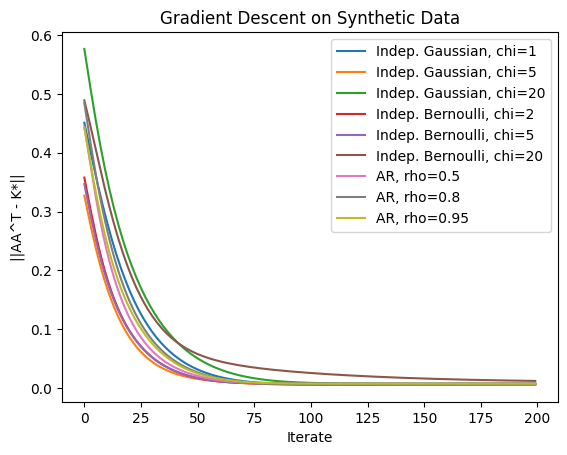

In [5]:
for d in list(gd_out.keys())[:9]:
    plt.plot(gd_out[d]["0"], label=df_to_name[d])
plt.legend()
plt.xlabel("Iterate")
plt.ylabel("||AA^T - K*||")
plt.title("Gradient Descent on Synthetic Data")
plt.savefig("gd_synthetic_data.png")

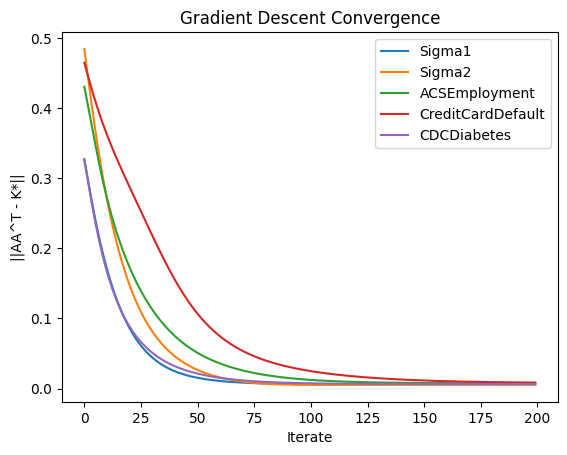

In [13]:
plt.plot(gd_out["gaussian.5"]["0"], label="Sigma1")
plt.plot(gd_out["ar.5"]["0"], label="Sigma2")
plt.plot(gd_out["ACSEmployment"]["0"][:200], label="ACSEmployment")
plt.plot(gd_out["CreditCardDefault"]["0"][:200], label="CreditCardDefault")
plt.plot(gd_out["CDCDiabetes"]["0"][:200], label="CDCDiabetes")
plt.legend()
plt.xlabel("Iterate")
plt.ylabel("||AA^T - K*||")
plt.title("Gradient Descent Convergence")
plt.savefig("gd_data_short.png")

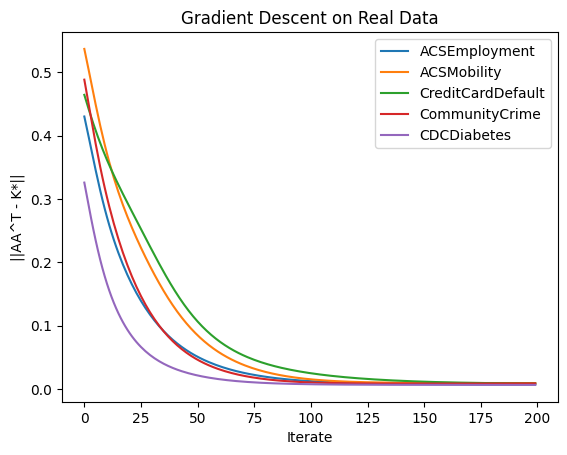

In [37]:
for d in list(gd_out.keys())[6:]:
    plt.plot(gd_out[d]["0"][:200], label=df_to_name[d])
plt.legend()
plt.xlabel("Iterate")
plt.ylabel("||AA^T - K*||")
plt.title("Gradient Descent on Real Data")
plt.savefig("gd_real_data.png")

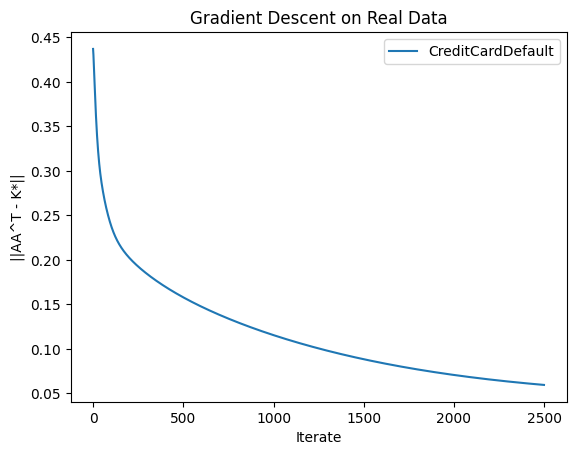

In [9]:
plt.plot(gd_out["CreditCardDefault"]["0"], label="CreditCardDefault")
plt.legend()
plt.xlabel("Iterate")
plt.ylabel("||AA^T - K*||")
plt.title("Gradient Descent on Real Data")
plt.savefig("gd_real_data.png")

In [30]:
gd_out["credit"]

,Unnamed: 0,dists
0,0,0.810850
1,1,0.771445
2,2,0.741254
3,3,0.715327
4,4,0.691751
...,...,...
852,852,0.008340
853,853,0.008340
854,854,0.008340
855,855,0.008340
